# Self-Training with STaR: Teaching Small Models to Reason

This notebook implements **STaR (Self-Taught Reasoner)** — an iterative self-training method where a language model improves by training on its own successful reasoning chains, plus rationalized explanations for problems it initially gets wrong.

We run STaR on **ARC-Challenge** (multiple-choice science reasoning) with **Qwen2.5-3B** at 4-bit quantization, demonstrating a 66% → 75% accuracy improvement over 3 iterations.

> **Looking for ReST-EM?** EM is one of the most underappreciated algorithms in ML. We give ReST-EM the treatment it deserves in a dedicated tutorial that traces the full EM lineage — from K-means and GMMs through HMMs and topic models to modern LLM self-training. Coming soon.

## Setup and Dependencies

We support both **`uv`** (recommended, faster) and **`pip`** (Colab default). The cell below auto-detects which is available.

In [1]:
import shutil
import subprocess
import sys

# Auto-detect installer: prefer uv, fall back to pip
UV_AVAILABLE = shutil.which("uv") is not None
installer = "uv pip" if UV_AVAILABLE else f"{sys.executable} -m pip"

if UV_AVAILABLE:
    print("Using uv (detected on PATH)")
    subprocess.check_call(
        [
            "uv",
            "pip",
            "install",
            "-q",
            "transformers>=4.40.0",
            "torch",
            "bitsandbytes",
            "peft",
            "trl>=0.8.0",
            "datasets",
            "accelerate",
            "matplotlib",
            "pandas",
        ]
    )
else:
    print(
        "Using pip (uv not found — install uv for faster setup:"
        "https://docs.astral.sh/uv/)"
    )
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "transformers>=4.40.0",
            "torch",
            "bitsandbytes",
            "peft",
            "trl>=0.8.0",
            "datasets",
            "accelerate",
            "matplotlib",
            "pandas",
        ]
    )

import warnings

warnings.filterwarnings("ignore")

import json
import re
import time
from collections import defaultdict
from typing import Dict, List, Tuple

import numpy as np
import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from trl import SFTConfig, SFTTrainer

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

print("\n✓ All dependencies loaded successfully")
print(f"✓ Installer: {'uv' if UV_AVAILABLE else 'pip'}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Using uv (detected on PATH)

✓ All dependencies loaded successfully
✓ Installer: uv
✓ CUDA available: True
✓ GPU: NVIDIA H100 80GB HBM3


## Cell 3: Background — The Self-Training Family Tree

Self-training is a form of **semi-supervised learning** where models learn from their own predictions. The progression:

### Evolution of Self-Training for LLMs

**Self-Instruct** (Wang et al., 2023)
- First systematic approach: seed instructions → generate data → filter → fine-tune
- Insight: Models can generate diverse, high-quality training data

**STaR** (Zelikman et al., 2023) — Self-Taught Reasoner
- Focus: Improve reasoning on math/QA tasks
- Key innovation: **Rationalization**
  - If model produces wrong answer → give correct answer as hint → ask for reasoning
  - Collect these (hint, reasoning) pairs as training data
  - This forces model to learn *why* the answer is correct
- Process: Direct attempt → If wrong, rationalize → Fine-tune on rationales

**ReST-EM** (Asai et al., 2024) — Reinforced Self-Training with EM
- Focus: General self-training framework via EM lens
- Key innovation: **Multi-sample generation** + **Reward-based filtering**
- Process: 
  1. **Grow** (E-step): Generate K samples per problem, keep correct ones
  2. **Improve** (M-step): Fine-tune on the grown dataset
  3. Repeat
- Advantage: Naturally incorporates reward signal (correctness)

**Connection to Self-Play / Proposer-Solver-Verifier**
- STaR: Model acts as Proposer (tries) + Solver (reasons under constraint)
- ReST: Model is Proposer (generates multiple), Verifier is external (correctness check)
- Both avoid needing human annotations for intermediate steps

### Conceptual Comparison

| Aspect | STaR | ReST-EM |
|--------|------|----------|
| **Samples per problem** | 1 (direct) + 1 (rationalize if wrong) | K (often K=8) |
| **Filtering** | Correctness | Correctness |
| **Training signal** | "Explain why this is correct" | "Fine-tune on all correct solutions" |
| **Iteration** | Direct → Rationalize → FT | Grow → Improve loop |
| **Best for** | Smaller models, reasoning-heavy tasks | General data collection |

### Why This Matters
Self-training creates a **positive feedback loop**:
1. Model solves a problem correctly
2. Collect high-quality solution (with reasoning / multiple paths)
3. Fine-tune on this data
4. Model improves → solves more problems → more training data

This is how **small models can improve dramatically without human annotation**.

## Cell 4: Load Model & Data

In [2]:
# Configuration
MODEL_NAME = "Qwen/Qwen2.5-3B"  # or "microsoft/Phi-3-mini-4k-instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Multi-GPU detection and setup
NUM_GPUS = torch.cuda.device_count()
MULTI_GPU = NUM_GPUS > 1

print(f"Loading model: {MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"Number of GPUs: {NUM_GPUS}")
print(f"Multi-GPU mode: {MULTI_GPU}")

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load base model once
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

# For multi-GPU: create replica for each GPU
if MULTI_GPU:
    models = []
    for gpu_id in range(NUM_GPUS):
        model_replica = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map={"": gpu_id},
            trust_remote_code=True,
            attn_implementation="sdpa",
        )
        models.append(model_replica)
    model = models[0]  # Primary model for reference
    print(f"✓ Loaded {NUM_GPUS} model replicas (one per GPU)")
else:
    models = [base_model]
    model = base_model
    print(f"✓ Single GPU mode: using base model")

print(f"✓ Model loaded: {MODEL_NAME}")
print(f"✓ Tokenizer vocab size: {len(tokenizer)}")

# Load ARC-Challenge dataset
# Why ARC-Challenge instead of GSM8K? Qwen2.5-3B-4bit gets ~22% on GSM8K —
# too far below the Zone of Proximal Development for self-training to show
# improvement. ARC-Challenge (4-choice science reasoning) puts the model at
# ~35-45%, right in the ZPD sweet spot. Multiple-choice also gives bulletproof
# answer verification (exact match on A/B/C/D).
print("\nLoading ARC-Challenge dataset...")
dataset = load_dataset("allenai/ai2_arc", "ARC-Challenge")

# Use subsets for faster training
np.random.seed(42)
train_indices = np.random.choice(len(dataset["train"]), 300, replace=False)
eval_indices = np.random.choice(len(dataset["test"]), 200, replace=False)

train_data = dataset["train"].select(train_indices)
eval_data = dataset["test"].select(eval_indices)

print(f"✓ Training set: {len(train_data)} problems")
print(f"✓ Eval set: {len(eval_data)} problems")
print(f"\nExample problem:")
example = train_data[0]
choices_text = "\n".join(
    f"  {label}) {text}"
    for label, text in zip(example["choices"]["label"], example["choices"]["text"])
)
print(f"Q: {example['question']}\n{choices_text}")
print(f"Answer: {example['answerKey']}")

Loading model: Qwen/Qwen2.5-3B
Device: cuda
Number of GPUs: 8
Multi-GPU mode: True


Loading weights: 100%|█████████████████| 434/434 [00:01<00:00, 399.15it/s]


✓ Loaded 8 model replicas (one per GPU)
✓ Model loaded: Qwen/Qwen2.5-3B
✓ Tokenizer vocab size: 151665

Loading ARC-Challenge dataset...
✓ Training set: 300 problems
✓ Eval set: 200 problems

Example problem:
Q: The day before the class is going to do a lab experiment, their teacher reminds them not to wear open shoes to school the next day. Which rationale best explains their teacher's request?
  A) to prevent spills of chemicals
  B) to prevent injury to toes or feet
  C) to keep them from getting tired feet
  D) to keep them grounded in case of shock
Answer: B


## Cell 5: Helper Functions

In [3]:
from concurrent.futures import ThreadPoolExecutor, as_completed


def extract_answer(text: str) -> str:
    """
    Extract answer letter (A/B/C/D) from model output.
    Tries several patterns: "Answer: B", "#### B", "(B)", or last
    standalone letter A-D in the text.
    """
    # Try explicit answer patterns first
    for pattern in [
        r"[Aa]nswer[:\s]+([A-D])",  # "Answer: B" or "answer B"
        r"####\s*([A-D])",  # "#### B"
        r"\(([A-D])\)",  # "(B)"
        r"\b([A-D])\b\s*$",  # Trailing standalone letter
    ]:
        match = re.search(pattern, text)
        if match:
            return match.group(1).upper()

    # Fallback: last standalone A-D in text
    matches = re.findall(r"\b([A-D])\b", text)
    if matches:
        return matches[-1].upper()

    return None


def parse_answer_key(example: dict) -> str:
    """
    Parse ARC-Challenge answer key from dataset example.
    Returns the answer letter (A/B/C/D).
    """
    return example["answerKey"].upper()


def format_choices(example: dict) -> str:
    """
    Format answer choices as a readable string.
    Example: "A) Shady areas increased.\nB) Food sources increased.\n..."
    """
    return "\n".join(
        f"{label}) {text}"
        for label, text in zip(example["choices"]["label"], example["choices"]["text"])
    )


def format_direct_prompt(question: str, choices: str = "") -> str:
    """
    Format prompt for direct solving (chain-of-thought).
    For ARC-Challenge: includes answer choices.
    """
    return f"""Question: {question}

{choices}

Think step by step, then give your final answer as a single letter (A, B, C, or D).

Answer:"""


def format_rationalization_prompt(
    question: str, correct_answer: str, choices: str = ""
) -> str:
    """
    Format prompt for rationalization (STaR-style).
    Given correct answer, generate a chain-of-thought that arrives at it.

    IMPORTANT: The output format must match format_direct_prompt() so that
    the model learns to produce the answer letter during evaluation.
    """
    return f"""Question: {question}

{choices}

The correct answer is {correct_answer}. Think step by step about why this is correct, then give your final answer as a single letter (A, B, C, or D).

Answer:"""


def generate_solution(
    model, tokenizer, prompt: str, max_new_tokens: int = 256, temperature: float = 0.7
) -> str:
    """
    Generate a solution using the model.

    Note: We use model.device (not a global DEVICE string) so inputs always land
    on the same GPU as the model replica. This is critical for multi-GPU setups
    where ThreadPoolExecutor dispatches to models on different devices.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Remove the prompt from response
    response = response[len(prompt) :].strip()
    return response


def sync_lora_weights(models: list, lora_config=None):
    """
    After fine-tuning on GPU 0, sync LoRA adapters to all other GPU replicas.

    FIX: The previous version was a no-op — replicas were plain base models
    with no LoRA parameters, so the inner loop found nothing to copy. This
    version applies get_peft_model() to each replica (creating the LoRA
    layers) and then overwrites them with the trained weights from GPU 0.
    """
    from peft import PeftModel

    if not MULTI_GPU or len(models) <= 1:
        return

    if lora_config is None:
        raise ValueError("lora_config is required to apply LoRA to replicas")

    # Collect trained LoRA weights from primary model (GPU 0)
    lora_state = {}
    for name, param in models[0].named_parameters():
        if "lora" in name.lower():
            lora_state[name] = param.data.clone()

    if not lora_state:
        print("⚠ No LoRA weights found on primary model — skipping sync")
        return

    # Apply LoRA to each replica, then copy trained weights
    for i in range(1, len(models)):
        # Unload existing adapter if present from previous iteration
        if isinstance(models[i], PeftModel):
            models[i] = models[i].unload()

        # Prepare replica for LoRA
        for p in models[i].parameters():
            p.requires_grad = False
        models[i].enable_input_require_grads()

        # Apply same LoRA architecture (initializes with random weights)
        models[i] = get_peft_model(models[i], lora_config)

        # Overwrite random init with trained weights from primary
        for name, param in models[i].named_parameters():
            if "lora" in name.lower() and name in lora_state:
                param.data.copy_(lora_state[name].to(param.device))

        # Replicas are inference-only
        models[i].eval()

    print(
        f"✓ Synced LoRA adapters to {len(models) - 1} replicas "
        f"({len(lora_state)} LoRA params each)"
    )


def _generate_for_gpu(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int,
    temperature: float,
):
    """
    Worker function for ThreadPoolExecutor: generate on assigned GPU.
    """
    return generate_solution(model, tokenizer, prompt, max_new_tokens, temperature)


def generate_solutions_parallel(
    models: list,
    tokenizer,
    prompts: list,
    max_new_tokens: int = 256,
    temperature: float = 0.7,
) -> list:
    """
    Generate solutions in parallel across GPUs using chunked dispatch.

    We use ThreadPoolExecutor (not multiprocessing) because model.generate()
    releases the GIL into CUDA kernels, giving us real GPU parallelism while
    keeping zero-copy access to model replicas in shared memory.

    Prompts are partitioned into per-GPU chunks so each GPU stays continuously
    busy (avoids the low-utilization problem of naive round-robin dispatch).
    See companion tutorial: "Threads, Processes, and GPUs" for the full story.

    Args:
        models: List of model replicas (one per GPU)
        tokenizer: Shared tokenizer
        prompts: List of prompts to generate
        max_new_tokens: Max tokens per generation
        temperature: Sampling temperature
    Returns:
        List of generated responses in same order as prompts
    """
    if not MULTI_GPU or len(models) <= 1:
        # Single GPU: sequential generation
        return [
            generate_solution(
                models[0],
                tokenizer,
                p,
                max_new_tokens,
                temperature,
            )
            for p in prompts
        ]

    num_gpus = len(models)
    responses = [None] * len(prompts)

    # Partition prompts into per-GPU chunks (dataset-agnostic)
    chunks = [[] for _ in range(num_gpus)]
    index_maps = [[] for _ in range(num_gpus)]
    for idx, prompt in enumerate(prompts):
        gpu_id = idx % num_gpus
        chunks[gpu_id].append(prompt)
        index_maps[gpu_id].append(idx)

    def _process_chunk(model, chunk, mk, temp):
        """Each thread processes its entire chunk sequentially."""
        return [generate_solution(model, tokenizer, p, mk, temp) for p in chunk]

    with ThreadPoolExecutor(max_workers=num_gpus) as executor:
        futures = {}
        for gpu_id in range(num_gpus):
            if not chunks[gpu_id]:
                continue
            future = executor.submit(
                _process_chunk,
                models[gpu_id],
                chunks[gpu_id],
                max_new_tokens,
                temperature,
            )
            futures[future] = gpu_id

        # Map results back to original indices
        for future in as_completed(futures):
            gpu_id = futures[future]
            results = future.result()
            for orig_idx, result in zip(index_maps[gpu_id], results):
                responses[orig_idx] = result

    return responses


def evaluate_accuracy(
    models, tokenizer, eval_data, num_samples: int = None, max_new_tokens: int = 256
) -> float:
    """
    Evaluate model accuracy on eval set using all available GPUs.

    Important: This function accepts the full `models` list (not a single model)
    and dispatches evaluation prompts across all GPUs via generate_solutions_parallel.
    On an 8-GPU setup, this is ~8x faster than single-GPU sequential evaluation.
    Without parallelization, even a 100-sample eval becomes a bottleneck that
    leaves 7 out of 8 GPUs completely idle.

    Args:
        models: List of model replicas (one per GPU), or a single model
        tokenizer: Shared tokenizer
        eval_data: Evaluation dataset
        num_samples: Number of samples to evaluate (default: all)
        max_new_tokens: Max tokens per generation

    Returns: accuracy (0-1)
    """
    if num_samples is None:
        num_samples = len(eval_data)

    n = min(num_samples, len(eval_data))

    # Handle both single model and model list for backward compatibility
    if not isinstance(models, list):
        models = [models]

    # Build all eval prompts
    questions = [eval_data[i]["question"] for i in range(n)]
    ground_truths = [parse_answer_key(eval_data[i]) for i in range(n)]
    choices_list = [format_choices(eval_data[i]) for i in range(n)]
    prompts = [format_direct_prompt(q, c) for q, c in zip(questions, choices_list)]

    # Generate all responses in parallel across GPUs
    responses = generate_solutions_parallel(
        models, tokenizer, prompts, max_new_tokens=max_new_tokens, temperature=0.1
    )

    # Score
    correct = sum(
        1
        for response, gt in zip(responses, ground_truths)
        if extract_answer(response) == gt
    )

    return correct / n


print("✓ Helper functions defined")
print("  - extract_answer(): Parse answer letter (A/B/C/D) from text")
print("  - parse_answer_key(): Get correct answer from ARC-Challenge example")
print("  - format_choices(): Format multiple-choice options as text")
print("  - format_direct_prompt(): Chain-of-thought prompt with choices")
print("  - format_rationalization_prompt(): Constrained generation prompt")
print("  - generate_solution(): Model inference")
print("  - sync_lora_weights(): Sync LoRA across GPUs")
print("  - generate_solutions_parallel(): Parallel generation across GPUs")
print("  - evaluate_accuracy(): Compute accuracy on eval set")

✓ Helper functions defined
  - extract_answer(): Parse answer letter (A/B/C/D) from text
  - parse_answer_key(): Get correct answer from ARC-Challenge example
  - format_choices(): Format multiple-choice options as text
  - format_direct_prompt(): Chain-of-thought prompt with choices
  - format_rationalization_prompt(): Constrained generation prompt
  - generate_solution(): Model inference
  - sync_lora_weights(): Sync LoRA across GPUs
  - generate_solutions_parallel(): Parallel generation across GPUs
  - evaluate_accuracy(): Compute accuracy on eval set


### Engineering Callout: Silent Failures in Distributed Weight Sync

The `sync_lora_weights` function above contains a defensive check that deserves explanation. An earlier version of this code had a subtle bug: it iterated over each replica's `named_parameters()` looking for LoRA weights to overwrite — but the replicas were plain base models that had never been wrapped with `get_peft_model()`. The loop found zero parameters with `"lora"` in their name, copied nothing, and **printed "✓ Synced" anyway**.

This is a pattern that plagues distributed ML broadly: operations that **succeed syntactically** (no exceptions, no crashes) but are **semantic no-ops**. The model appeared to train, evaluation ran without errors, and accuracy stayed flat — nothing pointed to the sync as the culprit.

**How we caught it:** Adding a parameter count to the sync log (`{len(lora_state)} LoRA params each`). When that printed `0`, the bug was obvious.

**Defensive patterns worth adopting:**

```python
# BAD: silent success on zero work
for name, param in replica.named_parameters():
    if "lora" in name:
        param.data.copy_(source[name])  # never executes if no LoRA layers
print("✓ Synced")  # lies

# GOOD: assert that work actually happened
copied = 0
for name, param in replica.named_parameters():
    if "lora" in name and name in source:
        param.data.copy_(source[name])
        copied += 1
assert copied > 0, f"Sync copied 0 params — replica may not have LoRA layers"
print(f"✓ Synced {copied} LoRA params")
```

> **Rule of thumb:** Any distributed operation that moves data between devices should log *how much* data moved. If the answer is zero, that's almost always a bug, not an optimization.

# Part 1: STaR Implementation

## Cell 6: Concept — STaR's Key Innovation: Rationalization

### The Problem
When a model fails to solve a problem, why does it fail? 
- Often: It gets a calculation wrong, or misunderstands the problem
- The failure might be early in the reasoning, or at the end

### The Insight (STaR)
If we tell the model the **correct answer** and ask it to explain why, it often can!

**Why does this work?**
1. Model knows what to "aim for" → less uncertainty about the goal
2. Model can reason backwards: "If the answer is X, what steps lead there?"
3. Conditioned reasoning is easier than open-ended reasoning
4. We get high-quality rationales showing correct reasoning paths

### Example

**Direct attempt (fails):**
```
Q: If a book costs $15 and you buy 3, how much total?
Model output: "3 books × $15 = $40"  [WRONG]
```

**Rationalization (succeeds):**
```
Q: If a book costs $15 and you buy 3, how much total?
Answer: 45
"Please explain why 45 is correct:"
Model output: "Each book costs $15. We buy 3 books. 3 × $15 = $45. So the total is $45."
[Collect this as training pair: (question, answer_hint, rationale)]
```

### Training on Rationalization
After fine-tuning on these (question, explanation) pairs:
- Model learns correct reasoning patterns
- When asked directly next time: better chance of getting it right
- Because it has learned the intermediate steps, not just memorized answers

### Why Not Just Use Correct Answers?
- Direct answer alone doesn't teach reasoning
- Rationalization forces step-by-step understanding
- This is why STaR > naive self-distillation on reasoning tasks

### Engineering Callout: Training-Eval Format Alignment

There's a subtle trap in rationalization-based self-training: **the training format can silently diverge from the evaluation format**.

Consider what happens if your rationalization prompt produces training text like:

```
The correct answer is B because electrons in the outer shell...
Therefore, the answer is B.
```

But your evaluation prompt expects:

```
Think step by step, then give your final answer as a single letter (A, B, C, or D).

Answer: B
```

The model trains on one distribution but is tested on another. It might learn perfectly good reasoning from rationalizations, yet still fail at evaluation because it never learned to produce the `Answer: X` format that `extract_answer()` parses.

**The fix is architectural, not cosmetic.** Look at `format_rationalization_prompt` above — its output format deliberately matches `format_direct_prompt`. Both end with the same structure: question, choices, step-by-step instruction, then `Answer:`. The rationalization just adds a hint ("The correct answer is {X}") to guide reasoning, while keeping the output format identical.

This matters more than it sounds. In an earlier version of this notebook, training used a different prompt template than evaluation. The model's accuracy stayed flat across iterations — not because it wasn't learning, but because it was learning to produce text in a format the evaluator couldn't parse.

> **Rule of thumb:** Your `format_rationalization_prompt` should be a strict superset of `format_direct_prompt` — same structure with an added hint, never a different structure.

## Cell 7: Implement — Generate Rationale

In [4]:
def generate_direct_attempt(
    model, tokenizer, question: str, choices: str = ""
) -> Tuple[str, str]:
    """
    Try to solve the problem directly.
    Args:
        model: Single model replica (any GPU)
        tokenizer: Shared tokenizer
        question: Problem question
        choices: Formatted answer choices
    Returns: (full_response, extracted_answer)
    """
    prompt = format_direct_prompt(question, choices)
    response = generate_solution(
        model,
        tokenizer,
        prompt,
        max_new_tokens=256,
        temperature=0.7,
    )
    answer = extract_answer(response)
    return response, answer


def generate_rationalization(
    model,
    tokenizer,
    question: str,
    correct_answer: str,
    choices: str = "",
) -> str:
    """
    Given correct answer, generate explanation (rationalization).
    Args:
        model: Single model replica (any GPU)
        tokenizer: Shared tokenizer
        question: Problem question
        correct_answer: Known correct answer
        choices: Formatted answer choices
    Returns: Rationalization text
    """
    prompt = format_rationalization_prompt(question, correct_answer, choices)
    explanation = generate_solution(
        model,
        tokenizer,
        prompt,
        max_new_tokens=256,
        temperature=0.7,
    )
    return explanation


# Test on a few examples
print("Testing direct attempt and rationalization...\n")

test_example = train_data[0]
test_question = test_example["question"]
test_choices = format_choices(test_example)
test_answer = parse_answer_key(test_example)

print(f"Question: {test_question[:200]}...")
print(f"{test_choices}")
print(f"Ground truth answer: {test_answer}\n")

# Direct attempt (using primary model)
print("=== Direct Attempt ===")
direct_response, direct_answer = generate_direct_attempt(
    model,
    tokenizer,
    test_question,
    test_choices,
)
print(f"Model's answer: {direct_answer}")
print(f"Response (first 300 chars): {direct_response[:300]}...\n")

# Rationalization
print("=== Rationalization ===")
rationalization = generate_rationalization(
    model, tokenizer, test_question, test_answer, test_choices
)
print(f"Rationalization (first 300 chars): {rationalization[:300]}...\n")
print("✓ Rationalization generation works")

Testing direct attempt and rationalization...

Question: The day before the class is going to do a lab experiment, their teacher reminds them not to wear open shoes to school the next day. Which rationale best explains their teacher's request?...
A) to prevent spills of chemicals
B) to prevent injury to toes or feet
C) to keep them from getting tired feet
D) to keep them grounded in case of shock
Ground truth answer: B

=== Direct Attempt ===
Model's answer: A
Response (first 300 chars): The correct answer is A) to prevent spills of chemicals....

=== Rationalization ===
Rationalization (first 300 chars): B

Explanation: The teacher's request to wear closed shoes to school the day before a lab experiment is most likely to prevent injury to the students' toes or feet. Open shoes can cause injuries if they come into contact with sharp objects, chemicals, or other potential hazards found in the lab. Thi...

✓ Rationalization generation works


## Cell 8: Implement — STaR Iteration

In [5]:
def run_star_iteration(
    models, tokenizer, train_data, iteration: int = 1, num_samples: int = None
) -> Dict:
    """
    Run one STaR iteration with multi-GPU support:
    1. For each problem, try to solve directly (distribute across GPUs)
    2. If wrong, generate rationalization with correct answer
    3. Collect (question, rationale) pairs

    Args:
        models: List of model replicas (one per GPU, or single-GPU list with one model)
        tokenizer: Shared tokenizer
        train_data: Training dataset
        iteration: Iteration number (for logging)
        num_samples: Number of samples to process

    Returns: (training_pairs, stats_dict)
    """
    if num_samples is None:
        num_samples = len(train_data)

    training_pairs = []  # List of (question, rationale) for fine-tuning
    stats = {"direct_correct": 0, "rationalized": 0, "total_processed": 0}

    print(f"STaR Iteration {iteration}: Processing {num_samples} problems...")
    print(f"  Mode: {'Multi-GPU' if MULTI_GPU else 'Single-GPU'}")

    # Batch generation for direct attempts (multi-GPU)
    if MULTI_GPU:
        # Generate direct attempts in parallel
        questions = []
        choices_list = []
        indices = []
        for i in range(min(num_samples, len(train_data))):
            questions.append(train_data[i]["question"])
            choices_list.append(format_choices(train_data[i]))
            indices.append(i)

        # Generate all direct attempts in parallel
        prompts = [format_direct_prompt(q, c) for q, c in zip(questions, choices_list)]
        responses = generate_solutions_parallel(
            models,
            tokenizer,
            prompts,
            max_new_tokens=256,
            temperature=0.7,
        )

        # Process results: separate correct vs needs-rationalization
        failed_items = []  # (original_idx, question, ground_truth)
        for idx, i in enumerate(indices):
            question = train_data[i]["question"]
            ground_truth = parse_answer_key(train_data[i])
            direct_response = responses[idx]
            direct_answer = extract_answer(direct_response)

            stats["total_processed"] += 1

            if direct_answer == ground_truth:
                stats["direct_correct"] += 1
                training_pairs.append(
                    {
                        "question": question,
                        "rationale": direct_response,
                        "answer": ground_truth,
                        "choices": choices_list[idx],
                        "source": "direct",
                    }
                )
            else:
                failed_items.append((idx, question, ground_truth))

        # Batch rationalize failed items across all GPUs (round-robin,
        # same ThreadPoolExecutor strategy as direct attempts — see companion
        # tutorial "Threads, Processes, and GPUs" for why threads beat
        # multiprocessing for CUDA workloads)
        if failed_items:
            rat_prompts = [
                format_rationalization_prompt(q, a, choices_list[orig_idx])
                for orig_idx, q, a in failed_items
            ]
            rationalizations = generate_solutions_parallel(
                models,
                tokenizer,
                rat_prompts,
                max_new_tokens=256,
                temperature=0.7,
            )
            for (orig_idx, question, gt), rationalization in zip(
                failed_items, rationalizations
            ):
                stats["rationalized"] += 1
                training_pairs.append(
                    {
                        "question": question,
                        "rationale": rationalization,
                        "answer": gt,
                        "choices": choices_list[orig_idx],
                        "source": "rationalization",
                    }
                )

        processed = stats["total_processed"]
        if processed % 50 == 0 or processed == num_samples:
            print(f"  Processed {processed}/{num_samples}")
    else:
        # Single-GPU sequential path (backward compatible)
        for i in range(min(num_samples, len(train_data))):
            question = train_data[i]["question"]
            ground_truth = parse_answer_key(train_data[i])
            choices = format_choices(train_data[i])

            # Step 1: Try direct solving
            direct_response, direct_answer = generate_direct_attempt(
                models[0],
                tokenizer,
                question,
                choices,
            )

            stats["total_processed"] += 1

            if direct_answer == ground_truth:
                stats["direct_correct"] += 1
                training_pairs.append(
                    {
                        "question": question,
                        "rationale": direct_response,
                        "answer": ground_truth,
                        "choices": choices,
                        "source": "direct",
                    }
                )
            else:
                # Direct attempt failed -> rationalize
                rationalization = generate_rationalization(
                    models[0],
                    tokenizer,
                    question,
                    ground_truth,
                    choices,
                )
                stats["rationalized"] += 1
                training_pairs.append(
                    {
                        "question": question,
                        "rationale": rationalization,
                        "answer": ground_truth,
                        "choices": choices,
                        "source": "rationalization",
                    }
                )

            if (i + 1) % 50 == 0:
                print(f"  Processed {i + 1}/{num_samples}")

    print(f"✓ Iteration {iteration} complete")
    print(f"  Direct correct: {stats['direct_correct']}/{stats['total_processed']}")
    print(f"  Rationalized: {stats['rationalized']}/{stats['total_processed']}")
    print(f"  Training pairs collected: {len(training_pairs)}")

    return training_pairs, stats


print("✓ STaR iteration function defined")

✓ STaR iteration function defined


## Cell 9: Implement — Fine-tune with LoRA

In [6]:
from datasets import Dataset


def prepare_training_data(training_pairs: List[Dict], tokenizer):
    """
    Format training pairs as prompt/completion pairs for SFTTrainer.

    Uses separate 'prompt' and 'completion' columns so that
    completion_only_loss=True in SFTConfig computes loss only on
    the model's reasoning + answer, not the question/choices.
    This replaces the removed DataCollatorForCompletionOnlyLM.
    """
    prompts = []
    completions = []
    for pair in training_pairs:
        rationale = pair["rationale"]
        answer = pair.get("answer", "")
        choices = pair.get("choices", "")

        # Safety net: ensure rationale contains the answer letter
        if answer and f"Answer: {answer}" not in rationale:
            rationale = rationale.rstrip() + f"\nAnswer: {answer}"

        # Prompt matches the evaluation format exactly
        prompt = f"""Question: {pair["question"]}

{choices}

Think step by step, then give your final answer as a single letter (A, B, C, or D).

Answer:"""
        prompts.append(prompt)
        completions.append(f" {rationale}")

    return Dataset.from_dict({"prompt": prompts, "completion": completions})


def finetune_model(
    models,
    tokenizer,
    training_texts,
    iteration: int = 1,
    method: str = "STaR",
    num_epochs: int = 3,
):
    """
    Fine-tune model on collected training data using SFTTrainer + LoRA.
    In multi-GPU mode, trains on GPU 0 then syncs LoRA weights to replicas.

    Why single-GPU training? Two reasons:
    1. bitsandbytes 4-bit layers can't survive DataParallel replication --
       the quantized weight tensors use custom CUDA storage that breaks when
       PyTorch tries to scatter them across devices, causing CUDA illegal
       memory access errors.
    2. It's actually fine for our use case: LoRA only trains ~3% of params,
       so training is fast even on 1 GPU. The real bottleneck in self-play
       is generation (autoregressive, token-by-token), which we DO
       parallelize across all GPUs. Training on ~200 examples takes
       seconds; generating 800 solutions takes minutes.

    For larger models where single-GPU training is too slow, use FSDP
    (Fully Sharded Data Parallel) instead of DataParallel -- see the
    distributed-training-fsdp tutorial.

    Args:
        models: List of model replicas
        tokenizer: Shared tokenizer
        training_texts: Training examples formatted as text
        iteration: Iteration number (for logging)
        method: Method name for output dir (STaR or ReST)
        num_epochs: Number of training epochs

    Returns: models list (updated with trained weights)
    """
    from peft import PeftModel

    print(
        f"\n{method}"
        + f" Iteration {iteration}"
        + f": Fine-tuning on {len(training_texts)}"
        + f" examples..."
    )

    # Always train on primary model (GPU 0)
    primary_model = models[0]

    # Unload existing LoRA adapter if present from previous iteration.
    # IMPORTANT: use unload(), NOT merge_and_unload(). On 4-bit models,
    # merge_and_unload() re-quantizes merged weights back to NF4, which
    # is lossy and compounds across iterations.
    if isinstance(primary_model, PeftModel):
        primary_model = primary_model.unload()
        models[0] = primary_model

    # Prepare model for k-bit training
    for param in primary_model.parameters():
        param.requires_grad = False
    primary_model.enable_input_require_grads()

    # LoRA config
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj"],  # Typical attention projection layers
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )

    primary_model = get_peft_model(primary_model, lora_config)
    primary_model.print_trainable_parameters()

    # Training arguments
    # completion_only_loss=True: loss is computed only on the completion
    # (the model's reasoning + answer), not on the prompt (question/choices).
    # This replaces the removed DataCollatorForCompletionOnlyLM class.
    training_args = SFTConfig(
        output_dir=f"/tmp/{method.lower()}_iter{iteration}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=2,
        warmup_steps=2,
        logging_steps=1,
        save_steps=100,
        learning_rate=2e-4,
        bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
        optim="paged_adamw_8bit",
        remove_unused_columns=False,
        report_to="none",
        completion_only_loss=True,
        max_length=512,
        packing=False,
    )

    # Prevent DataParallel — train on GPU 0 only.
    # bitsandbytes 4-bit layers can't survive DataParallel replication
    # across GPUs (causes CUDA illegal memory access). This is fine:
    # LoRA training is fast (~3% params); the real bottleneck is
    # generation, which uses all GPUs in parallel.
    _real_device_count = torch.cuda.device_count
    torch.cuda.device_count = lambda: 1

    # Trainer
    trainer = SFTTrainer(
        model=primary_model,
        processing_class=tokenizer,
        args=training_args,
        train_dataset=training_texts,
    )

    # Train
    start_time = time.time()
    trainer.train()
    elapsed = time.time() - start_time
    torch.cuda.device_count = _real_device_count

    print(f"✓ Fine-tuning complete ({elapsed:.1f}s)")

    # Update models list with fine-tuned model
    models[0] = primary_model

    # Sync LoRA weights to other replicas
    if MULTI_GPU and len(models) > 1:
        sync_lora_weights(models, lora_config=lora_config)

    return models


print("✓ Training data preparation and fine-tuning functions defined")

✓ Training data preparation and fine-tuning functions defined


## Cell 10: Run STaR — 3 Iterations

In [7]:
# Track metrics across iterations
star_metrics = {
    "iterations": [],
    "accuracy": [],
    "direct_correct": [],
    "rationalized": [],
    "training_examples": [],
}

# Initial accuracy (using primary model)
print("Computing initial accuracy...")
initial_accuracy = evaluate_accuracy(models, tokenizer, eval_data, num_samples=100)
print(f"Initial accuracy: {initial_accuracy:.4f}\n")
star_metrics["accuracy"].append(initial_accuracy)
star_metrics["iterations"].append(0)

# Accumulate training data across iterations so the model learns from
# ALL prior rounds.  Since finetune_model calls unload() (to avoid lossy
# 4-bit merge_and_unload), each iteration starts from the base model --
# accumulated data is what carries knowledge forward.
all_training_pairs = []

# STaR iterations
for iteration in range(1, 4):
    print(f"\n{'=' * 60}")
    print(f"STaR ITERATION {iteration}")
    print(f"{'=' * 60}")

    # Step 1: Collect training data via rationalization (multi-GPU generation)
    training_pairs, stats = run_star_iteration(
        models, tokenizer, train_data, iteration, num_samples=100
    )

    star_metrics["direct_correct"].append(stats["direct_correct"])
    star_metrics["rationalized"].append(stats["rationalized"])
    star_metrics["training_examples"].append(len(training_pairs))

    # Accumulate training data from all iterations
    all_training_pairs.extend(training_pairs)

    # Step 2: Fine-tune on ALL accumulated data (trains on GPU 0, syncs to others)
    training_texts = prepare_training_data(all_training_pairs, tokenizer)
    models = finetune_model(
        models,
        tokenizer,
        training_texts,
        iteration,
        "STaR",
        num_epochs=3,
    )

    # Step 3: Evaluate (using primary model)
    print(f"\nEvaluating after iteration {iteration}...")
    accuracy = evaluate_accuracy(models, tokenizer, eval_data, num_samples=100)
    star_metrics["accuracy"].append(accuracy)
    star_metrics["iterations"].append(iteration)

    print(f"Accuracy after iteration {iteration}: {accuracy:.4f}")
    print(f"Improvement: {accuracy - star_metrics['accuracy'][iteration - 1]:.4f}")

print(f"\n{'=' * 60}")
print(f"STaR Training Complete")
print(f"{'=' * 60}")

Computing initial accuracy...
Initial accuracy: 0.6600


STaR ITERATION 1
STaR Iteration 1: Processing 100 problems...
  Mode: Multi-GPU
  Processed 100/100
✓ Iteration 1 complete
  Direct correct: 69/100
  Rationalized: 31/100
  Training pairs collected: 100

STaR Iteration 1: Fine-tuning on 100 examples...
trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Adding EOS to train dataset: 100%|█| 100/100 [00:00<00:00, 12305.79 exampl
Tokenizing train dataset: 100%|█| 100/100 [00:00<00:00, 1202.85 examples/s
Truncating train dataset: 100%|█| 100/100 [00:00<00:00, 44025.44 examples/
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,4.007830
2,3.915033
3,3.619923
4,4.300372
5,3.795212
6,3.555159
7,3.270120
8,2.609496
9,3.373992
10,3.054305


✓ Fine-tuning complete (10.1s)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


...

Step,Training Loss
1,6.532763
2,8.080837
3,3.897745
4,5.500648
5,5.170671
6,5.365671
7,3.534916
8,5.870496
9,5.067119
10,5.490381


✓ Fine-tuning complete (17.9s)
✓ Synced LoRA adapters to 7 replicas (144 LoRA params each)

Evaluating after iteration 2...
Accuracy after iteration 2: 0.7400
Improvement: 0.0500

STaR ITERATION 3
STaR Iteration 3: Processing 100 problems...
  Mode: Multi-GPU
  Processed 100/100
✓ Iteration 3 complete
  Direct correct: 66/100
  Rationalized: 34/100
  Training pairs collected: 100

STaR Iteration 3: Fine-tuning on 300 examples...
trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Adding EOS to train dataset: 100%|█| 300/300 [00:00<00:00, 34273.72 exampl
Tokenizing train dataset: 100%|█| 300/300 [00:00<00:00, 1735.99 examples/s
Truncating train dataset: 100%|█| 300/300 [00:00<00:00, 123325.61 examples


Step,Training Loss
1,4.396596
2,7.859465
3,5.601276
4,5.884253
5,6.639264
6,6.674196
7,4.999954
8,8.196201
9,7.622703
10,2.712922


✓ Fine-tuning complete (26.1s)
✓ Synced LoRA adapters to 7 replicas (144 LoRA params each)

Evaluating after iteration 3...
Accuracy after iteration 3: 0.7500
Improvement: 0.0100

STaR Training Complete


In [7]:
# Track metrics across iterations
star_metrics = {
    "iterations": [],
    "accuracy": [],
    "direct_correct": [],
    "rationalized": [],
    "training_examples": [],
}

# Initial accuracy (using primary model)
print("Computing initial accuracy...")
initial_accuracy = evaluate_accuracy(models, tokenizer, eval_data, num_samples=100)
print(f"Initial accuracy: {initial_accuracy:.4f}\n")
star_metrics["accuracy"].append(initial_accuracy)
star_metrics["iterations"].append(0)

# Accumulate training data across iterations so the model learns from
# ALL prior rounds.  Since finetune_model calls unload() (to avoid lossy
# 4-bit merge_and_unload), each iteration starts from the base model --
# accumulated data is what carries knowledge forward.
all_training_pairs = []

# STaR iterations
for iteration in range(1, 4):
    print(f"\n{'=' * 60}")
    print(f"STaR ITERATION {iteration}")
    print(f"{'=' * 60}")

    # Step 1: Collect training data via rationalization (multi-GPU generation)
    training_pairs, stats = run_star_iteration(
        models, tokenizer, train_data, iteration, num_samples=100
    )

    star_metrics["direct_correct"].append(stats["direct_correct"])
    star_metrics["rationalized"].append(stats["rationalized"])
    star_metrics["training_examples"].append(len(training_pairs))

    # Accumulate training data from all iterations
    all_training_pairs.extend(training_pairs)

    # Step 2: Fine-tune on ALL accumulated data (trains on GPU 0, syncs to others)
    training_texts = prepare_training_data(all_training_pairs, tokenizer)
    models = finetune_model(
        models,
        tokenizer,
        training_texts,
        iteration,
        "STaR",
        num_epochs=3,
    )

    # Step 3: Evaluate (using primary model)
    print(f"\nEvaluating after iteration {iteration}...")
    accuracy = evaluate_accuracy(models, tokenizer, eval_data, num_samples=100)
    star_metrics["accuracy"].append(accuracy)
    star_metrics["iterations"].append(iteration)

    print(f"Accuracy after iteration {iteration}: {accuracy:.4f}")
    print(f"Improvement: {accuracy - star_metrics['accuracy'][iteration - 1]:.4f}")

print(f"\n{'=' * 60}")
print(f"STaR Training Complete")
print(f"{'=' * 60}")

Computing initial accuracy...
Initial accuracy: 0.6600


STaR ITERATION 1
STaR Iteration 1: Processing 100 problems...
  Mode: Multi-GPU
  Processed 100/100
✓ Iteration 1 complete
  Direct correct: 69/100
  Rationalized: 31/100
  Training pairs collected: 100

STaR Iteration 1: Fine-tuning on 100 examples...
trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Adding EOS to train dataset: 100%|█| 100/100 [00:00<00:00, 12305.79 exampl
Tokenizing train dataset: 100%|█| 100/100 [00:00<00:00, 1202.85 examples/s
Truncating train dataset: 100%|█| 100/100 [00:00<00:00, 44025.44 examples/
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,4.007830
2,3.915033
3,3.619923
4,4.300372
5,3.795212
6,3.555159
7,3.270120
8,2.609496
9,3.373992
10,3.054305


✓ Fine-tuning complete (10.1s)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


...

Step,Training Loss
1,6.532763
2,8.080837
3,3.897745
4,5.500648
5,5.170671
6,5.365671
7,3.534916
8,5.870496
9,5.067119
10,5.490381


✓ Fine-tuning complete (17.9s)
✓ Synced LoRA adapters to 7 replicas (144 LoRA params each)

Evaluating after iteration 2...
Accuracy after iteration 2: 0.7400
Improvement: 0.0500

STaR ITERATION 3
STaR Iteration 3: Processing 100 problems...
  Mode: Multi-GPU
  Processed 100/100
✓ Iteration 3 complete
  Direct correct: 66/100
  Rationalized: 34/100
  Training pairs collected: 100

STaR Iteration 3: Fine-tuning on 300 examples...
trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Adding EOS to train dataset: 100%|█| 300/300 [00:00<00:00, 34273.72 exampl
Tokenizing train dataset: 100%|█| 300/300 [00:00<00:00, 1735.99 examples/s
Truncating train dataset: 100%|█| 300/300 [00:00<00:00, 123325.61 examples


Step,Training Loss
1,4.396596
2,7.859465
3,5.601276
4,5.884253
5,6.639264
6,6.674196
7,4.999954
8,8.196201
9,7.622703
10,2.712922


✓ Fine-tuning complete (26.1s)
✓ Synced LoRA adapters to 7 replicas (144 LoRA params each)

Evaluating after iteration 3...
Accuracy after iteration 3: 0.7500
Improvement: 0.0100

STaR Training Complete


## Cell 11: Analyze STaR Results


STaR RESULTS SUMMARY

Accuracy Progression:
  Iteration 0: 0.6600
  Iteration 1: 0.6900
    → Improvement: +0.0300
  Iteration 2: 0.7400
    → Improvement: +0.0500
  Iteration 3: 0.7500
    → Improvement: +0.0100

Training Data Composition:
  Iteration 1:
    Direct correct: 69/100 (69.0%)
    Rationalized: 31/100 (31.0%)
  Iteration 2:
    Direct correct: 59/100 (59.0%)
    Rationalized: 41/100 (41.0%)
  Iteration 3:
    Direct correct: 66/100 (66.0%)
    Rationalized: 34/100 (34.0%)


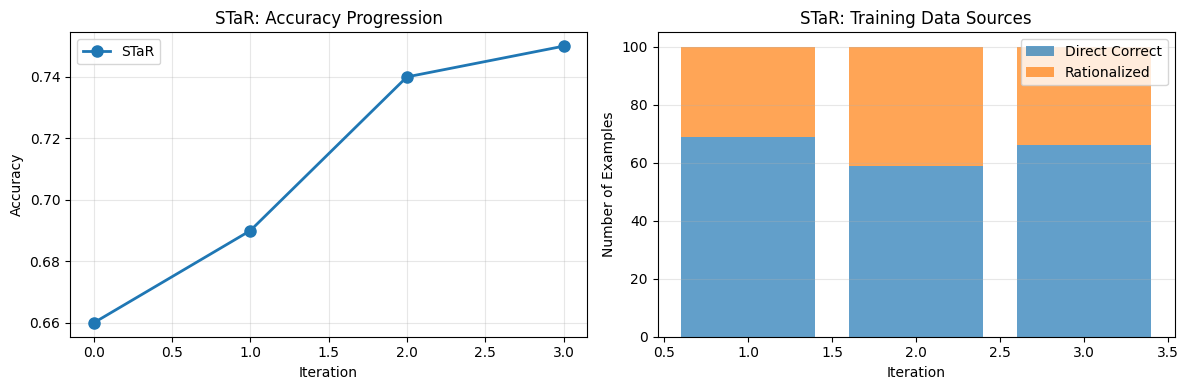


✓ Plots saved to /tmp/star_results.png


In [8]:
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("STaR RESULTS SUMMARY")
print("=" * 60 + "\n")

# Accuracy progression
print("Accuracy Progression:")
for i, (iter_num, acc) in enumerate(
    zip(star_metrics["iterations"], star_metrics["accuracy"]),
):
    print(f"  Iteration {iter_num}: {acc:.4f}")
    if i > 0:
        improvement = acc - star_metrics["accuracy"][i - 1]
        print(f"    → Improvement: {improvement:+.4f}")

# Training data composition
print(f"\nTraining Data Composition:")
for i, iter_num in enumerate(star_metrics["iterations"][1:], 1):  # Skip iteration 0
    direct = star_metrics["direct_correct"][i - 1]
    rational = star_metrics["rationalized"][i - 1]
    total = direct + rational
    print(f"  Iteration {iter_num}:")
    print(f"    Direct correct: {direct}/{total} ({100 * direct / total:.1f}%)")
    print(f"    Rationalized: {rational}/{total} ({100 * rational / total:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Accuracy over iterations
axes[0].plot(
    star_metrics["iterations"],
    star_metrics["accuracy"],
    "o-",
    linewidth=2,
    markersize=8,
    label="STaR",
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("STaR: Accuracy Progression")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Training data composition
iterations_train = list(range(1, len(star_metrics["direct_correct"]) + 1))
axes[1].bar(
    iterations_train,
    star_metrics["direct_correct"],
    label="Direct Correct",
    alpha=0.7,
)
axes[1].bar(
    iterations_train,
    star_metrics["rationalized"],
    bottom=star_metrics["direct_correct"],
    label="Rationalized",
    alpha=0.7,
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Number of Examples")
axes[1].set_title("STaR: Training Data Sources")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/tmp/star_results.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\n✓ Plots saved to /tmp/star_results.png")

### Practical Note: "My Loss Is Spiking — Is Training Broken?"

If you ran the STaR loop above, you likely noticed that **training loss becomes spikier in later iterations** — iteration 1 might show a smooth 2–4 range, while iterations 2–3 spike to 8, 10, or even 15+. This looks alarming, but it's expected behavior. Here's why:

**Theory says:** Loss should decrease monotonically during supervised fine-tuning on well-formed data.

**Practice says:** Three compounding factors make later-iteration loss noisier:

1. **Rationalization quality degrades on harder examples.** Iteration 1 rationalizes the "just barely missed" questions — the model can usually produce clean chain-of-thought for these. By iteration 3, the remaining wrong questions are the genuinely hard ones. Their rationalizations tend to be longer, more convoluted, or contain reasoning artifacts — each one carries higher per-token loss.

2. **Fresh LoRA each iteration resets the adapter.** We apply a new LoRA adapter at each iteration (to avoid compounding errors), so the trainer starts from scratch on an increasingly heterogeneous dataset — a mix of easy examples (from earlier iterations' correct answers) and hard rationalized ones. The loss landscape is bumpier.

3. **Small effective batch size amplifies outliers.** With `per_device_train_batch_size=2` and `gradient_accumulation_steps=2` (effective batch = 4), a single pathologically long or noisy rationalization can dominate an entire mini-batch's loss. That's often the source of an isolated spike to 15+.

**The metric that matters is accuracy, not per-step loss.** Our accuracy curve (66% → 69% → 74% → 75%) is monotonically increasing — the model is genuinely learning. The loss *trend* within each iteration is still generally downward; the spikes are outlier batches, not training collapse.

> **Smoothing levers (if you need them):**  
> - Increase `gradient_accumulation_steps` to 4 or 8 — larger effective batch averages out outlier examples  
> - Add a `max_seq_length` cutoff to drop pathologically long rationalizations  
> - Use gradient clipping (already set via `max_grad_norm=1.0` in SFTConfig)  
>
> For this tutorial, the raw results tell the honest story — spiky loss with improving accuracy is a normal signature of iterative self-training on small models.

### Practical Note: Choosing the Right Task for Your Model's Capability

Before writing a single line of self-training code, you need to answer: **is my model in the right capability range for this task?** Getting this wrong wastes all downstream effort — and the failure mode is silent.

#### What Happened to Us

We originally ran this notebook on **GSM8K** (grade-school math). Qwen2.5-3B at 4-bit quantization scored **22% base accuracy** — roughly 1-in-5 problems correct. After 3 STaR iterations with correctly implemented sync, format alignment, and training: **accuracy stayed flat at 17–23%**, bouncing around the baseline.

The model wasn't broken. The *pairing* was broken. A 3B model at 4-bit quantization simply doesn't have enough latent math reasoning capability for STaR's rationalization to unlock. When asked to rationalize a problem it got wrong, it produced plausible-looking but logically flawed chains — garbage in, garbage out.

We switched to **ARC-Challenge** (multiple-choice science reasoning). Same model, same code, same hyperparameters. Base accuracy: **66%**. After 3 STaR iterations: **75%** — a clean +9 percentage point improvement.

#### The Zone of Proximal Development (ZPD)

This maps directly to Vygotsky's concept from educational psychology: learning happens in the zone between what a learner can do independently and what they can do with scaffolding.

For self-training, the "scaffolding" is rationalization (STaR) or multiple sampling (ReST). The model needs enough base capability to produce *some* correct reasoning when guided, but not so much that it's already solving everything.

| Base Accuracy | Zone | Self-Training Outcome |
|:---:|:---:|:---|
| < 25% | Below ZPD | Rationalizations are noise. Training on them teaches wrong patterns. Accuracy stagnates or drops. |
| 25–45% | Lower ZPD | Possible but fragile. Needs many iterations, careful hypertuning, and high-quality verification. |
| 45–75% | Sweet spot | Model has enough capability for rationalization to work. Clear improvement expected across iterations. |
| > 75% | Above ZPD | Diminishing returns. Few problems left to improve on. Consider harder benchmarks or larger scale. |

#### How to Check Before You Commit

Before running your self-training loop, evaluate your model's base accuracy on the target task. This takes minutes and saves hours:

```python
# Quick ZPD check — run this BEFORE any self-training
base_acc = evaluate_accuracy(models, tokenizer, test_data, desc="ZPD check")
print(f"Base accuracy: {base_acc:.1%}")

if base_acc < 0.25:
    print("⚠ Below ZPD — consider an easier task or a larger model")
elif base_acc > 0.75:
    print("⚠ Above ZPD — consider a harder task for meaningful gains")
else:
    print("✓ In ZPD — proceed with self-training")
```

#### The Model-Size / Task-Difficulty Tradeoff

With model families now spanning 0.5B to 70B+ parameters (Qwen2.5, Llama 3.x, Phi-3.5), the question isn't just "which model" — it's "which model *for this task* on *this hardware*." A 7B model might be in the ZPD for GSM8K, while a 3B model at 4-bit needs an easier task like ARC-Challenge. The self-training method doesn't change; only the capability-difficulty pairing does.

> **Rule of thumb:** If your base accuracy is below 30% and you can't scale up the model (budget, hardware), scale down the task difficulty instead. A successful self-training run on an appropriate task teaches you far more than a failed run on an impressive-sounding benchmark.

## What About ReST-EM?

ReST-EM ([Singh et al., 2023](https://arxiv.org/abs/2308.08998)) takes a different approach to self-training by framing it as **Expectation-Maximization**: generate K candidate solutions and keep the correct ones (E-step), then fine-tune on the filtered set (M-step).

We originally implemented ReST-EM side-by-side with STaR in this notebook, but it deserves far more than a sidebar. EM is one of the most underappreciated algorithms in machine learning — it connects self-training to a rich lineage spanning K-means, Gaussian mixtures, HMMs, topic models, and variational inference. Understanding that connection fundamentally changes how you think about the Grow/Improve loop.

We give ReST-EM the treatment it deserves in a **dedicated tutorial** that traces EM from classical foundations to modern LLM self-training, with a toy EM notebook for building intuition and a full ReST-EM implementation that connects every code cell back to the probabilistic formalism.

> **Coming soon:** *The EM Algorithm — From Classical Foundations to LLM Self-Training*

## Connection to Self-Play and Proposer-Solver-Verifier

Recall from the trends tutorial: self-play decomposes tasks into specialized roles. STaR maps cleanly onto this framework:

| Role | STaR Mapping |
|---|---|
| **Proposer** | Model tries to solve directly (generate rationale + answer) |
| **Solver** | Model explains under constraint — rationalization with correct answer given |
| **Verifier** | Deterministic correctness check (extract answer, compare to ground truth) |

The key insight: in STaR, **all three roles are played by the same model**. The model proposes solutions (direct attempts), refines via rationalization (given the correct answer as a hint), and is verified by a simple answer-matching check. This self-contained loop is what makes STaR practical on modest hardware.

Why this works: the model learns from its own successful proposals. Failed attempts are filtered by the deterministic verifier. Each iteration produces a better model, which generates more correct solutions, which produces even better training data — a positive feedback loop.

### Evolution Toward Specialized Roles

STaR represents the simplest point in a spectrum of increasing specialization:

1. **Self-Training (STaR):** Same model for all roles — simple but effective for many tasks
2. **ReST-EM:** Same idea framed as EM — Grow/Improve loop with theoretical grounding (covered in a dedicated upcoming tutorial)
3. **Outcome-based reward models:** Separate Verifier — more nuanced signals than binary correctness
4. **Process-based reward models:** Separate Solver — learns to prefer good intermediate steps
5. **Full specialization:** Separate Proposer, Solver, Verifier — maximum efficiency but complex training pipeline

STaR is the foundation: proving that self-training alone can improve small models. More advanced approaches add specialized components on top.

## Exercises and Extensions

These exercises deepen understanding and extend the STaR implementation.

### Level 1: Modify Hyperparameters

**Exercise 1.1 — LoRA Configuration:** Try different rank values (r = 8, 16, 32). Smaller rank means fewer parameters and faster training. Does rank affect convergence speed or final accuracy?

**Exercise 1.2 — Iteration Count:** Run 5–7 STaR iterations instead of 3. Plot accuracy vs. iteration — does it plateau? Decline? When do diminishing returns kick in?

**Exercise 1.3 — Temperature for Rationalization:** Try temperature 0.3, 0.7, 1.0 during rationalization. Higher temperature should produce more diverse rationalizations — does that help or hurt training?

### Level 2: Deeper Analysis

**Exercise 2.1 — ZPD Exploration:** Run the same STaR loop on different datasets: ARC-Easy (expect ~85% base), ARC-Challenge (our ~66%), an MMLU subset. Plot base accuracy vs. STaR improvement to confirm or refine the ZPD boundaries from the practical note above.

**Exercise 2.2 — Rationalization Quality Audit:** Manually inspect 20 rationalizations from each iteration. How many have logically valid reasoning chains? Does rationalization quality degrade in later iterations?

**Exercise 2.3 — Supervised Fine-Tuning Baseline:** Fine-tune on 100 random ARC-Challenge examples with ground-truth labels. Compare STaR (self-generated data) vs. SFT (ground truth) — can self-training match supervised learning with the same compute?

### Level 3: Research Directions

**Exercise 3.1 — Process-Based Filtering:** Go beyond binary correctness. Parse reasoning steps from solutions and check for common mistakes. Does adding step-level validity filtering improve training data quality?

**Exercise 3.2 — Multi-Task Self-Training:** Mix ARC-Challenge (science) with commonsense QA. Does self-training on mixed tasks help generalization, or does it dilute the signal?

**Exercise 3.3 — Active Learning Variant:** Instead of random problems, select uncertain ones (where the model generates contradictory answers across samples). Does focusing on uncertain problems accelerate learning?

## Summary and Key Takeaways

### What We Learned

**The problem:** Small models (3B–13B) struggle on reasoning tasks, and getting more labeled data is expensive. Self-training lets a model learn from its own successful outputs.

**STaR (Self-Taught Reasoner):** The key insight is rationalization — when the model gets an answer wrong, give it the correct answer and ask it to explain why. Train on those explanations. Result: 66% → 75% on ARC-Challenge (+9 percentage points in 3 iterations).

**Model-task pairing (ZPD):** Base accuracy must be in the 30–75% sweet spot. Below that, rationalizations are noise (our GSM8K experience: 22% base, flat across iterations). Above that, diminishing returns. Always check base accuracy before committing GPU hours.

**Engineering lessons:**
- Silent failures — distributed sync can print success while copying zero parameters
- Format alignment — training text must match evaluation prompt structure exactly
- Completion-only loss — mask prompt tokens to focus gradient on the response
- Loss spikes in later iterations are normal if accuracy keeps improving

**Connection to self-play:** STaR = Proposer + Solver + Verifier (all same model). It's the foundation for more advanced techniques that add specialized components.

### What's Next

- **ReST-EM:** Self-training as Expectation-Maximization — a dedicated upcoming tutorial traces EM from classical foundations to LLM self-training
- **Outcome-based rewards:** Replace binary correctness with a scoring rubric
- **Process-based rewards:** Train a separate model to score intermediate reasoning steps
- **MCTS integration:** Use tree search to explore a larger solution space

---

*Notebook complete. You've implemented STaR from scratch and learned the engineering pitfalls that separate working self-training from broken. Try the exercises to deepen your understanding.*